In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image
import matplotlib as plt

import matplotlib.pyplot as plt



2025-12-03 23:04:06.261904: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
print("TensorFlow:,", tf.version)

TensorFlow: <module 'tensorflow._api.v2.version' from '/opt/anaconda3/envs/tfarm/lib/python3.9/site-packages/tensorflow/_api/v2/version/__init__.py'>


**DATENVORVERARBEITUNG**

**Daten laden + Batch und IMG size festelegen**

In [3]:
# Absoluter Projektpfad
PROJECT_ROOT = Path("/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning").resolve()
print("PROJECT_ROOT:", PROJECT_ROOT)

# (optional) Arbeitsverzeichnis setzen
os.chdir(PROJECT_ROOT)
print("cwd:", os.getcwd())

IMG_SIZE   = (224, 224) #
BATCH_SIZE = 32

# CSV liegt jetzt direkt in dataset2
CSV_PATH = PROJECT_ROOT / "dataset2" / "Multi-Label dataset - with augmented.csv"
print("CSV_PATH:", CSV_PATH)

df_raw = pd.read_csv(CSV_PATH)
print("df_raw shape:", df_raw.shape)
print("Spalten:", df_raw.columns.tolist())
df_raw.head()


PROJECT_ROOT: /Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning
cwd: /Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning
CSV_PATH: /Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning/dataset2/Multi-Label dataset - with augmented.csv
df_raw shape: (5653, 12)
Spalten: ['dataset', 'filename', 'path', 'Early blight', 'Healthy', 'Late blight', 'Leaf Miner', 'Magnesium Deficiency', 'Nitrogen Deficiency', 'Pottassium Deficiency', 'Spotted Wilt Virus', 'SUM']


,dataset,filename,path,Early blight,Healthy,Late blight,Leaf Miner,Magnesium Deficiency,Nitrogen Deficiency,Pottassium Deficiency,Spotted Wilt Virus,SUM
0,test,IMG20220323100545_1.jpg,\test\Early_blight,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,test,IMG20220323102226_1.jpg,\test\Early_blight,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,test,IMG20220323102423_7.jpg,\test\Early_blight,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,test,IMG20220323102851_4.jpg,\test\Early_blight,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,test,IMG20220323103905_4.jpg,\test\Early_blight,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


### Datenvorbereitung: Label-Definition, Pfadverknüpfung und Klassendistrbution

In diesem Schritt bereite ich den Multi-Label-Datensatz für das spätere Training vor:

1. **Definition der Krankheits-Labels**  
   Zunächst werden die relevanten Label-Spalten (z.B. *Early blight*, *Leaf Miner* etc.) festgelegt.  
   Es werden nur die Spalten verwendet, die tatsächlich in der CSV vorhanden sind.  
   Fehlende Werte werden durch `0` ersetzt (Krankheit liegt nicht vor) und alle Label-Spalten in `float32` konvertiert.

2. **Verknüpfung von CSV und Bilddateien**  
   Ausgehend vom Basisordner `dataset2` wird ein Index aufgebaut, der jedem `(split, filename)`-Paar den vollständigen Bildpfad zuordnet.  
   Der DataFrame `df` erhält eine zusätzliche Spalte `filepath`, in der zu jedem CSV-Eintrag der passende Bildpfad hinterlegt wird.  
   Zeilen ohne gültigen Pfad werden entfernt. Anschließend wird der Datensatz anhand der Spalte `dataset` in `train_df`, `val_df` und `test_df` aufgeteilt.

3. **Analyse der Label-Verteilung**  
   Für den gesamten Datensatz sowie getrennt nach Train/Validation/Test werden die Häufigkeiten der einzelnen Krankheiten gezählt und als Balkendiagramm visualisiert.  
   Dadurch wird sichtbar, dass die Klassen stark unausgeglichen sind (z.B. viele *Leaf Miner*-Beispiele, deutlich weniger seltene Krankheiten).

4. **Erzeugung eines balancierten Trainings-Sets**  
   Um das Klassenzuordnung beim Training auszugleichen, wird aus `train_df` ein balanciertes Trainings-Set `balanced_train_df` erzeugt.  
   Für jede Krankheit wird dabei eine maximale Anzahl von Beispielen (`max_per_label`) festgelegt:  
   - Häufige Klassen werden auf diesen Wert heruntergesampelt.  
   - Seltene Klassen werden durch Oversampling (mit Wiederholung) auf denselben Wert aufgefüllt.  
   Abschließend wird die Label-Verteilung im balancierten Trainings-Set erneut als Balkendiagramm dargestellt.

Damit ist die Datenbasis für das Multi-Label-CNN vorbereitet: Jeder Eintrag besitzt Bildpfad und Multi-Label-Vektor, die Splits sind definiert, und das Trainings-Set ist bzgl. der Krankheitsklassen künstlich balanciert.


Verwendete Krankheits-Labels: ['Early blight', 'Late blight', 'Leaf Miner', 'Magnesium Deficiency', 'Nitrogen Deficiency', 'Pottassium Deficiency', 'Spotted Wilt Virus']
NUM_LABELS: 7
BASE_DIR: /Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning/dataset2
Anzahl Dateien im Index: 5656
Zeilen ohne gefundenen Pfad: 0
df nach Filterung: (5653, 13)

Anzahl Samples:
  train_df: 3945
  val_df:   1124
  test_df:  584


,dataset,filename,filepath
0,test,IMG20220323100545_1.jpg,/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Proj...
1,test,IMG20220323102226_1.jpg,/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Proj...
2,test,IMG20220323102423_7.jpg,/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Proj...
3,test,IMG20220323102851_4.jpg,/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Proj...
4,test,IMG20220323103905_4.jpg,/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Proj...



Gesamt-Verteilung der Labels (df):
Early blight             : 579
Late blight              : 918
Leaf Miner               : 2101
Magnesium Deficiency     : 1518
Nitrogen Deficiency      : 469
Pottassium Deficiency    : 85
Spotted Wilt Virus       : 917


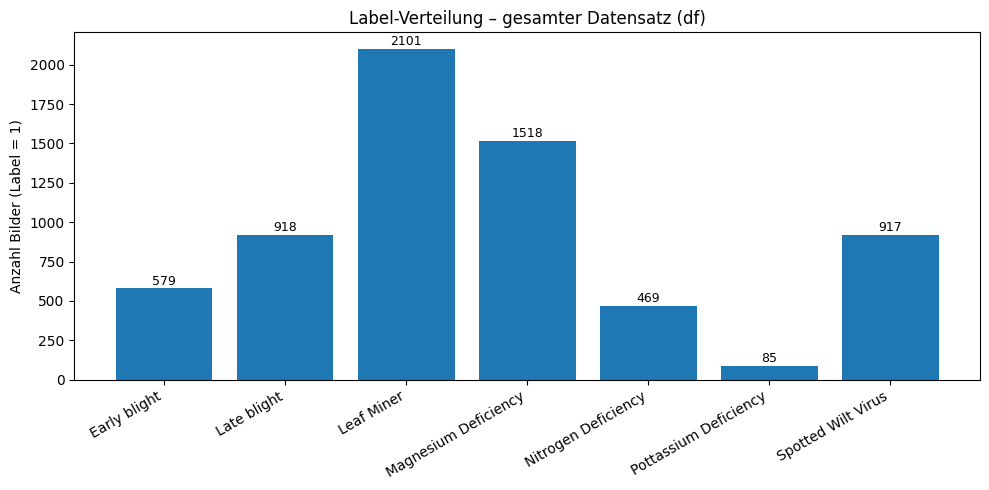

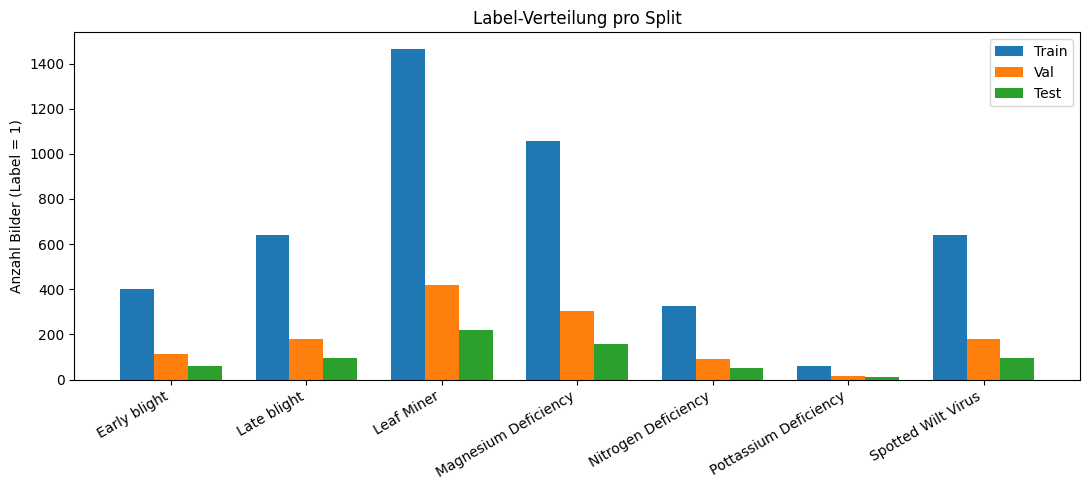


✅ Balanced Train Shape: (2157, 13)

Label-Verteilung im balancierten Train-Set:
Early blight             : 400
Late blight              : 401
Leaf Miner               : 700
Magnesium Deficiency     : 478
Nitrogen Deficiency      : 236
Pottassium Deficiency    : 59
Spotted Wilt Virus       : 430


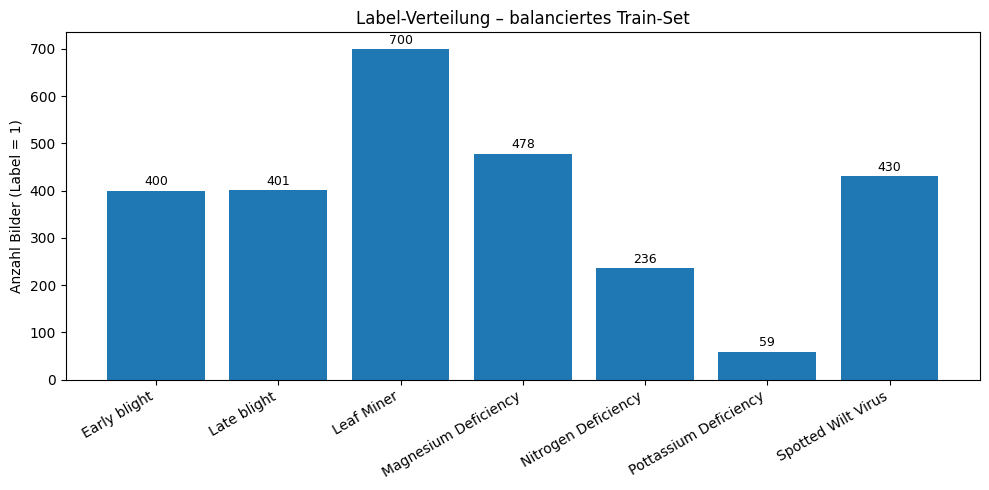

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------
# 1) Krankheits-Labels definieren
# ---------------------------------------------
DISEASE_COLS = [
    "Early blight",
    "Late blight",
    "Leaf Miner",
    "Magnesium Deficiency",
    "Nitrogen Deficiency",
    "Pottassium Deficiency",
    "Spotted Wilt Virus",
]

# Nur Spalten nutzen, die in der CSV wirklich existieren
DISEASE_COLS = [c for c in DISEASE_COLS if c in df_raw.columns]
NUM_LABELS   = len(DISEASE_COLS)
print("Verwendete Krankheits-Labels:", DISEASE_COLS)
print("NUM_LABELS:", NUM_LABELS)

# NaN -> 0, alles float32
df_raw[DISEASE_COLS] = df_raw[DISEASE_COLS].fillna(0).astype("float32")

# ---------------------------------------------
# 2) Pfade aufbauen und CSV verknüpfen
# ---------------------------------------------
BASE_DIR = PROJECT_ROOT / "dataset2"
print("BASE_DIR:", BASE_DIR)

# Index: (split, filename) -> voller Pfad
index = {}

for split in ["train", "val", "test"]:
    split_dir = BASE_DIR / split
    if not split_dir.is_dir():
        print(f"Warnung: {split_dir} existiert nicht")
        continue

    for p in split_dir.rglob("*"):
        if p.is_file():
            key = (split, p.name)       # z.B. ("train", "IMG2022....jpg")
            index[key] = str(p)

print("Anzahl Dateien im Index:", len(index))

# CSV mit Index verknüpfen
df = df_raw.copy()

def lookup_filepath(row):
    key = (str(row["dataset"]), str(row["filename"]))
    return index.get(key, None)

df["filepath"] = df.apply(lookup_filepath, axis=1)

missing = df["filepath"].isna().sum()
print("Zeilen ohne gefundenen Pfad:", missing)

# Nur Zeilen mit gültigem Pfad behalten
df = df[df["filepath"].notna()].reset_index(drop=True)
print("df nach Filterung:", df.shape)

# In train / val / test splitten
train_df = df[df["dataset"] == "train"].reset_index(drop=True)
val_df   = df[df["dataset"] == "val"].reset_index(drop=True)
test_df  = df[df["dataset"] == "test"].reset_index(drop=True)

print("\nAnzahl Samples:")
print("  train_df:", len(train_df))
print("  val_df:  ", len(val_df))
print("  test_df: ", len(test_df))

# Optional: Überblick über Dateipfade
display(df[["dataset", "filename", "filepath"]].head())

# =========================================================
# 3) NEU: Balkendiagramme zur Label-Verteilung
# =========================================================

# --- 3.1 Gesamt-Verteilung aller Labels über df ---
label_counts_total = df[DISEASE_COLS].sum().astype(int)

print("\nGesamt-Verteilung der Labels (df):")
for name, count in zip(DISEASE_COLS, label_counts_total):
    print(f"{name:25s}: {count}")

plt.figure(figsize=(10, 5))
bars = plt.bar(DISEASE_COLS, label_counts_total)

plt.ylabel("Anzahl Bilder (Label = 1)")
plt.title("Label-Verteilung – gesamter Datensatz (df)")

# Exakte Werte über den Balken
for bar, count in zip(bars, label_counts_total):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(count),
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# --- 3.2 Verteilung pro Split (Train / Val / Test) ---
train_counts = train_df[DISEASE_COLS].sum().astype(int)
val_counts   = val_df[DISEASE_COLS].sum().astype(int)
test_counts  = test_df[DISEASE_COLS].sum().astype(int)

x = np.arange(len(DISEASE_COLS))
width = 0.25

plt.figure(figsize=(11, 5))
b1 = plt.bar(x - width, train_counts, width, label="Train")
b2 = plt.bar(x,         val_counts,   width, label="Val")
b3 = plt.bar(x + width, test_counts,  width, label="Test")

plt.ylabel("Anzahl Bilder (Label = 1)")
plt.title("Label-Verteilung pro Split")
plt.xticks(x, DISEASE_COLS, rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 4) Balancierten Train-DataFrame erzeugen
# =========================================================

def make_balanced_train_df(train_df, label_cols, max_per_label=400, random_state=42):
    """
    Baut einen neuen Trainings-DataFrame, in dem jede Krankheit
    ungefähr gleich oft vorkommt (Oversampling/Downsampling).

    max_per_label:
        - Wenn eine Klasse mehr Bilder hat -> zufällig auf max_per_label reduziert.
        - Wenn eine Klasse weniger hat -> mit Wiederholung auf max_per_label aufgefüllt.
    """
    dfs = []

    for col in label_cols:
        df_pos = train_df[train_df[col] == 1]

        if len(df_pos) == 0:
            print(f"⚠️ Warnung: Keine Samples für Label '{col}' im Training gefunden.")
            continue

        if len(df_pos) >= max_per_label:
            df_bal = df_pos.sample(max_per_label, random_state=random_state)
        else:
            df_bal = df_pos.sample(max_per_label, replace=True, random_state=random_state)

        dfs.append(df_bal)

    balanced = pd.concat(dfs).drop_duplicates().reset_index(drop=True)

    print("\n✅ Balanced Train Shape:", balanced.shape)
    return balanced

balanced_train_df = make_balanced_train_df(
    train_df=train_df,
    label_cols=DISEASE_COLS,
    max_per_label=400,
    random_state=42
)

# --- 4.1 Balkendiagramm für den balancierten Train-DF ---
balanced_counts = balanced_train_df[DISEASE_COLS].sum().astype(int)

print("\nLabel-Verteilung im balancierten Train-Set:")
for name, count in zip(DISEASE_COLS, balanced_counts):
    print(f"{name:25s}: {count}")

plt.figure(figsize=(10, 5))
bars = plt.bar(DISEASE_COLS, balanced_counts)

plt.ylabel("Anzahl Bilder (Label = 1)")
plt.title("Label-Verteilung – balanciertes Train-Set")

for bar, count in zip(bars, balanced_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(count),
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [5]:
# Annahme: DISEASE_COLS ist schon definiert
print("Label-Häufigkeiten im Training:")
train_label_counts = train_df[DISEASE_COLS].sum().sort_values(ascending=False)
print(train_label_counts)


Label-Häufigkeiten im Training:
Leaf Miner               1465.0
Magnesium Deficiency     1058.0
Late blight               641.0
Spotted Wilt Virus        639.0
Early blight              403.0
Nitrogen Deficiency       326.0
Pottassium Deficiency      59.0
dtype: float32


In [6]:
print("TRAIN-Verteilung:")
print(train_df[DISEASE_COLS].sum())

print("\nVAL-Verteilung:")
print(val_df[DISEASE_COLS].sum())

print("\nTEST-Verteilung:")
print(test_df[DISEASE_COLS].sum())


TRAIN-Verteilung:
Early blight              403.0
Late blight               641.0
Leaf Miner               1465.0
Magnesium Deficiency     1058.0
Nitrogen Deficiency       326.0
Pottassium Deficiency      59.0
Spotted Wilt Virus        639.0
dtype: float32

VAL-Verteilung:
Early blight             115.0
Late blight              182.0
Leaf Miner               417.0
Magnesium Deficiency     302.0
Nitrogen Deficiency       93.0
Pottassium Deficiency     16.0
Spotted Wilt Virus       182.0
dtype: float32

TEST-Verteilung:
Early blight              61.0
Late blight               95.0
Leaf Miner               219.0
Magnesium Deficiency     158.0
Nitrogen Deficiency       50.0
Pottassium Deficiency     10.0
Spotted Wilt Virus        96.0
dtype: float32


### Aufbau der tf.data-Pipeline (Train/Validation/Test)

In diesem Abschnitt baue ich aus den vorbereiteten DataFrames (`train_df`, `val_df`, `test_df`) eine effiziente Eingabepipeline für TensorFlow:

1. **Funktion `make_multilabel_dataset_from_df(...)`**  
   - Nimmt einen beliebigen Split-DataFrame (`df_split`) entgegen.  
   - Liest die Bildpfade aus der Spalte `filepath` und die zugehörigen Multi-Label-Vektoren aus den Spalten `DISEASE_COLS`.  
   - Erzeugt daraus ein `tf.data.Dataset`, das zunächst Paare der Form `(Pfad, Labelvektor)` enthält.  
   - Über die Hilfsfunktion `_load_img(...)` werden die Bilder:
     - von der Festplatte gelesen,  
     - aus JPEG decodiert,  
     - auf die feste Eingangsgröße `IMG_SIZE` (z.B. 224×224 Pixel) skaliert.  
   - Optional werden die Daten (abhängig vom Parameter `shuffle`) zufällig gemischt.  
   - Anschließend werden die Daten in Batches der Größe `BATCH_SIZE` zusammengefasst und mit `prefetch` für eine effizientere GPU/CPU-Auslastung vorbereitet.

2. **Verwendung für Training, Validierung und Test**  
   - Für das Training wird bewusst das **balancierte** Trainings-DataFrame `balanced_train_df` verwendet, damit alle Krankheiten im Training ungefähr gleich stark vertreten sind.  
     - `train_ds = make_multilabel_dataset_from_df(balanced_train_df, shuffle=True)`  
     - Durch das Shuffling erhält das Modell jede Epoche eine andere Reihenfolge der Trainingsbeispiele.  
   - Für Validation und Test werden die **originalen**, unbalancierten DataFrames `val_df` und `test_df` genutzt, um die echte Verteilung im Datensatz widerzuspiegeln.  
     - `val_ds` und `test_ds` werden ohne Shuffling aufgebaut (`shuffle=False`), damit die Auswertung reproduzierbar bleibt.  
   - Ein kurzer Print-Test (`train_ds.take(1)`) prüft zuletzt, ob aus dem Dataset korrekt ein Batch von Bildern und den dazugehörigen Multi-Label-Targets erzeugt wird.

Damit ist die Datenpipeline fertig aufgebaut: Das Modell kann nun direkt mit Batches von vorverarbeiteten Bildern und den passenden Labelvektoren trainiert bzw. evaluiert werden.


In [7]:
"""""
def make_multilabel_dataset_from_df(df_split, shuffle=True):
    paths  = df_split["filepath"].values
    labels = df_split[DISEASE_COLS].values.astype("float32")  # (N, NUM_LABELS)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def _load_img(path, y):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        return img, y

    ds = ds.map(_load_img, num_parallel_calls=tf.data.AUTOTUNE)

    n = len(df_split)
    if shuffle and n > 0:
        ds = ds.shuffle(buffer_size=n, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_multilabel_dataset_from_df(train_df, shuffle=True)    
val_ds   = make_multilabel_dataset_from_df(val_df,   shuffle=False) #shuffle bei val einfügen
test_ds  = make_multilabel_dataset_from_df(test_df,  shuffle=False)

# Check: kommt wirklich ein Batch?
for xb, yb in train_ds.take(1):
    print("Batch-Bilder:", xb.shape, "Batch-Labels:", yb.shape)

"""""

def make_multilabel_dataset_from_df(df_split, shuffle=True):
    paths  = df_split["filepath"].values
    labels = df_split[DISEASE_COLS].values.astype("float32")  # (N, NUM_LABELS)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def _load_img(path, y):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        # ggf. /255.0 Normalisierung, falls du sie noch nicht woanders machst:
        # img = img / 255.0
        return img, y

    ds = ds.map(_load_img, num_parallel_calls=tf.data.AUTOTUNE)

    n = len(df_split)
    if shuffle and n > 0:
        ds = ds.shuffle(buffer_size=n, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# ⚠️ WICHTIG: Hier jetzt das BALANCIERTE train_df verwenden
train_ds = make_multilabel_dataset_from_df(balanced_train_df, shuffle=True)

# Validation und Test bleiben unbalanciert (echte Verteilung)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

val_ds   = make_multilabel_dataset_from_df(val_df,   shuffle=False)  # val normalerweise NICHT shufflen
test_ds  = make_multilabel_dataset_from_df(test_df,  shuffle=False)

# Check: kommt wirklich ein Batch?
for xb, yb in train_ds.take(1):
    print("Batch-Bilder:", xb.shape, "Batch-Labels:", yb.shape)


2025-12-02 19:54:25.191215: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-12-02 19:54:25.191663: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-02 19:54:25.191678: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-12-02 19:54:25.192035: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-02 19:54:25.192465: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-12-02 19:54:25.364937: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore th

Batch-Bilder: (32, 224, 224, 3) Batch-Labels: (32, 7)


2025-12-02 19:55:50.229151: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:417] Shuffle buffer filled.


### Modellarchitektur: Convolutional Neural Network für Multi-Label-Klassifikation

In dieser Funktion definiere ich das Convolutional Neural Network (CNN), mit dem die Blattkrankheiten als Multi-Label-Problem vorhergesagt werden.

1. **Eingabe und Data Augmentation**  
   - Das Modell erhält als Input ein RGB-Bild der Größe `IMG_SIZE` (z.B. 224×224×3).  
   - Über eine `keras.Sequential`-Schicht werden verschiedene Data-Augmentation-Operationen angewendet:  
     - horizontales Spiegeln,  
     - kleine Rotationen,  
     - Zoom,  
     - Translationen,  
     - zufällige Änderungen von Helligkeit und Kontrast.  
   - Dadurch wird künstlich zusätzliche Varianz erzeugt, was das Modell robuster macht und Overfitting reduziert.  
   - Anschließend werden die Pixelwerte mit `Rescaling(1./255)` auf den Bereich [0, 1] normalisiert.

2. **CNN-Backbone (Feature-Extraktion)**  
   - Das eigentliche CNN besteht aus vier Convolutional-Blöcken.  
   - Jeder Block enthält mehrere `Conv2D`-Schichten mit `ReLU`-Aktivierung, gefolgt von `MaxPooling2D`.  
   - Mit zunehmender Tiefe steigt die Anzahl der Filter (32 → 64 → 128 → 256), während die räumliche Auflösung durch Max-Pooling schrittweise reduziert wird.  
   - In diesen Schichten lernt das Modell automatisch immer komplexere Merkmale der Blattbilder (von einfachen Kanten bis hin zu krankheitsspezifischen Strukturen).

3. **Klassifikationskopf und Regularisierung**  
   - Nach den Convolution-Schichten wird mit `Dropout(0.5)` eine starke Regularisierung eingesetzt, um Overfitting zu vermeiden.  
   - `Flatten()` wandelt die 2D-Feature-Maps in einen eindimensionalen Vektor um.  
   - Eine voll vernetzte Dense-Schicht mit 256 Neuronen und `ReLU`-Aktivierung dient als hochdimensionale Repräsentation für die anschließende Klassifikation.  
   - Ein zweites `Dropout(0.5)` reduziert erneut die Gefahr von Overfitting.

4. **Multi-Label-Ausgabe**  
   - Die letzte Dense-Schicht besitzt `NUM_LABELS` Neuronen, jeweils eines pro Krankheit (z.B. *Early blight*, *Leaf Miner* usw.).  
   - Durch die `sigmoid`-Aktivierung wird für jede Krankheit eine unabhängige Wahrscheinlichkeit im Bereich [0, 1] ausgegeben.  
   - Dadurch können mehrere Krankheiten gleichzeitig als vorhanden markiert werden (Multi-Label-Setting), im Gegensatz zu einer klassischen Multi-Class-Softmax-Ausgabe.

Insgesamt handelt es sich somit um ein von Grund auf selbst definiertes CNN, das Bildmerkmale über mehrere Convolutional-Blöcke extrahiert und am Ende einen Multi-Label-Vektor mit Krankheitswahrscheinlichkeiten für jedes Blattbild liefert.


In [9]:
"""""
def make_plant_cnn_multilabel(input_shape=IMG_SIZE + (3,)):
    inputs = keras.Input(shape=input_shape)

#Dataaugmentation
    data_aug = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomBrightness(0.2),
        layers.RandomContrast(0.2),
    ], name="data_augmentation")

    #erschwerung des trainings um es dem modell das training nicht zu leicht zu machen und overfotting zu vermeiden
    #für jedes Bild im batch wird die Dataaug. durchgeführt. Bie jedem durchlauf etwas anders

    x = data_aug(inputs)
    x = layers.Rescaling(1./255, name="rescale")(x)

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 4 (optional)
    x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Dropout(0.5)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    # Multi-Label Output: NUM_LABELS Neuronen mit Sigmoid
    outputs = layers.Dense(
        NUM_LABELS,
        activation="sigmoid",
        name="multilabel_output"
    )(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="plant_cnn_multilabel")
    return model

plant_cnn = make_plant_cnn_multilabel()
plant_cnn.summary()

"""""

from tensorflow import keras
from tensorflow.keras import layers

def make_plant_cnn_multilabel(input_shape=IMG_SIZE + (3,)):
    inputs = keras.Input(shape=input_shape)

    # ----------------------------------------
    # Data Augmentation (etwas erweitert)
    # ----------------------------------------
    data_aug = keras.Sequential(
        [
            # Spiegeln links/rechts
            layers.RandomFlip("horizontal"),

            # Kleine Rotationen
            layers.RandomRotation(0.08, fill_mode="nearest"),

            # Leicht rein/rauszoomen
            layers.RandomZoom(0.1, fill_mode="nearest"),

            # Leichte Verschiebung nach oben/unten/links/rechts
            layers.RandomTranslation(0.05, 0.05, fill_mode="nearest"),

            # Helligkeit & Kontrast leicht variieren
            layers.RandomBrightness(0.15),
            layers.RandomContrast(0.2),
        ],
        name="data_augmentation",
    )

    # Augmentation + Rescaling
    x = data_aug(inputs)
    x = layers.Rescaling(1.0 / 255, name="rescale")(x)

    # ----------------------------------------
    # CNN-Backbone (wie bei dir)
    # ----------------------------------------
    # Block 1
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 4
    x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Regularisierung gegen Overfitting
    x = layers.Dropout(0.5)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    # Multi-Label Output: NUM_LABELS Neuronen mit Sigmoid
    outputs = layers.Dense(
        NUM_LABELS,
        activation="sigmoid",
        name="multilabel_output",
    )(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="plant_cnn_multilabel")
    return model




### Instanziierung und Übersicht des Modells

Nachdem die Architektur des CNN in der Funktion `make_plant_cnn_multilabel(...)` definiert wurde, wird in dieser Zelle das eigentliche Modellobjekt erzeugt und überprüft:

```python
plant_cnn = make_plant_cnn_multilabel()
plant_cnn.summary()


In [31]:
plant_cnn = make_plant_cnn_multilabel()
plant_cnn.summary()


Model: "plant_cnn_multilabel"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 rescale (Rescaling)         (None, 224, 224, 3)       0         
                                                                 
 conv2d_7 (Conv2D)           (None, 224, 224, 32)      896       
                                                                 
 conv2d_8 (Conv2D)           (None, 224, 224, 32)      9248      
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 112, 112, 32)     0         
 2D)                                          

### Training des Multi-Label-CNN mit gewichteter Loss-Funktion

In dieser Zelle wird das zuvor definierte CNN-Modell für die Multi-Label-Klassifikation trainiert.  
Aufgrund der stark unausgeglichenen Klassenverteilung (z.B. viele *Leaf Miner*, wenige *Spotted Wilt Virus*) verwende ich eine **gewichtete Binary Crossentropy**.

1. **Berechnung der Klassengewichte**  
   - Zunächst werden aus dem ursprünglichen, unbalancierten `train_df` die Häufigkeiten jeder Krankheit ermittelt.  
   - Für jedes Label wird ein Gewicht `pos_weight` berechnet als  
     \[
     \text{pos\_weight} = \frac{\text{Anzahl negative Beispiele}}{\text{Anzahl positive Beispiele}}
     \]  
   - Seltene Klassen erhalten dadurch größere Gewichte, sodass Fehler bei deren Erkennung stärker in die Loss-Funktion eingehen.

2. **Gewichtete Binary Crossentropy (`weighted_bce`)**  
   - Auf Basis der berechneten Gewichte wird eine eigene Loss-Funktion implementiert, die die Standard-Binary-Crossentropy um die positiven Klassengewichte erweitert.  
   - Positive Beispiele seltener Krankheiten werden dadurch im Training höher gewichtet, während häufige Klassen (z.B. *Leaf Miner*) nicht das gesamte Training dominieren.

3. **Kompilierung des Modells**  
   - Das Modell wird mit dem Adam-Optimizer (`learning_rate = 1e-4`) kompiliert.  
   - Als Loss-Funktion wird die gewichtete Binary Crossentropy (`weighted_bce`) verwendet.  
   - Als Metriken dienen die `BinaryAccuracy` (Anteil korrekt klassifizierter 0/1-Labels) und die `AUC` (Trennschärfe zwischen positiven und negativen Beispielen).

4. **Callbacks: EarlyStopping und ModelCheckpoint**  
   - `EarlyStopping` überwacht die Validierungs-Loss (`val_loss`) und bricht das Training ab, wenn sich diese über mehrere Epochen hinweg nicht mehr verbessert. Anschließend werden automatisch die besten Gewichte wiederhergestellt.  
   - `ModelCheckpoint` speichert zusätzlich das Modell mit der niedrigsten Validierungs-Loss als Datei (`plant_cnn_multilabel_weighted_best.keras`).

5. **Training mit balanciertem Trainings-Set**  
   - Das eigentliche Training erfolgt auf `train_ds`, welches auf dem balancierten `balanced_train_df` basiert (gleich viele Beispiele pro Krankheitslabel).  
   - Validierung und Test basieren weiterhin auf den originalen, unausgeglichenen Splits (`val_df`), um eine realistische Einschätzung der Modellleistung zu erhalten.  
   - Der Trainingsverlauf (Loss- und Metrik-Werte pro Epoche) wird im `history`-Objekt gespeichert.

6. **Speichern des finalen Modells**  
   - Nach Abschluss des Trainings wird das endgültige Modell unter dem Namen  
     `plant_cnn_from_scratch_multilabel_dataset2_weighted.keras` gespeichert und steht damit für Vorhersagen und weitere Auswertungen zur Verfügung.


In [32]:
"""""
import tensorflow as tf
from tensorflow import keras

# --------------------------------------------------
# 1) (Optional) Label-Häufigkeiten NUR zur Info
#    -> beeinflusst das Training NICHT
# --------------------------------------------------
print("Label-Häufigkeiten im Training:")
label_freq = train_df[DISEASE_COLS].sum().values.astype("float32")
for name, freq in zip(DISEASE_COLS, label_freq):
    print(f"{name:25s}: {freq:.0f}")

# --------------------------------------------------
# 2) Modell kompilieren – NORMALE binary_crossentropy
#    (kein Gewicht, kein Spezial-Loss)
# --------------------------------------------------
# Falls plant_cnn noch nicht existiert, vorher:
# plant_cnn = make_plant_cnn_multilabel()

# Standard: Adam
optimizer = keras.optimizers.Adam(learning_rate=1e-4)

# Wenn du später AdamW testen willst:
# from tensorflow.keras.optimizers import AdamW
# optimizer = AdamW(learning_rate=1e-4, weight_decay=1e-4)

plant_cnn.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",   # <--- ganz normale BCE
    metrics=[
        keras.metrics.BinaryAccuracy(name="bin_acc"),
        keras.metrics.AUC(name="auc"),
    ],
)

# --------------------------------------------------
# 3) Callbacks: EarlyStopping + ModelCheckpoint
# --------------------------------------------------
EPOCHS = 50   # kannst z.B. auch 40 oder 60 nehmen, EarlyStopping regelt

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

checkpoint = keras.callbacks.ModelCheckpoint(
    "plant_cnn_multilabel_unweighted_best.keras",  # neuer Dateiname
    monitor="val_loss",
    save_best_only=True,
)

# --------------------------------------------------
# 4) Training starten
# --------------------------------------------------
history = plant_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint],
)

# --------------------------------------------------
# 5) Finales Modell speichern
#    (nicht über dein altes gutes Modell drüberschreiben)
# --------------------------------------------------
plant_cnn.save("plant_cnn_from_scratch_multilabel_dataset2_unweighted.keras")
"""""

import tensorflow as tf
from tensorflow import keras

# --------------------------------------------------
# 1) Label-Häufigkeiten im ursprünglichen (UNBALANCIERTEN) train_df
#    -> brauchen wir für die Gewichte der Loss-Funktion
# --------------------------------------------------
print("Label-Häufigkeiten im ursprünglichen train_df:")
label_counts = train_df[DISEASE_COLS].sum().values.astype("float32")
for name, freq in zip(DISEASE_COLS, label_counts):
    print(f"{name:25s}: {freq:.0f}")

total_samples = float(len(train_df))
neg_counts = total_samples - label_counts

# Seltene Klassen sollen stärker gewichtet werden:
pos_weights = neg_counts / (label_counts + 1e-8)
pos_weights = tf.constant(pos_weights, dtype=tf.float32)

print("\nPositive class weights pro Label (für weighted BCE):")
for name, w in zip(DISEASE_COLS, pos_weights.numpy()):
    print(f"{name:25s}: {w:.2f}")


# --------------------------------------------------
# 2) Gewichtete Binary Crossentropy definieren
# --------------------------------------------------
def weighted_bce(y_true, y_pred):
    """
    Gewichtete Binary Crossentropy:
    - positive Beispiele für seltene Klassen werden stärker gewichtet.
    - nutzt pos_weights, die aus train_df berechnet wurden.
    """
    # Schutz vor log(0)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

    # pos_weights: Shape (NUM_LABELS,)
    # y_true, y_pred: (batch_size, NUM_LABELS)
    # Broadcasting kümmert sich darum, dass die Gewichte
    # auf jede Spalte (jede Krankheit) angewendet werden.
    pw = pos_weights

    loss_pos = -pw * y_true * tf.math.log(y_pred)
    loss_neg = -(1.0 - y_true) * tf.math.log(1.0 - y_pred)

    loss = loss_pos + loss_neg
    return tf.reduce_mean(loss)


# --------------------------------------------------
# 3) Modell kompilieren – mit gewichteter Loss
# --------------------------------------------------
# Falls plant_cnn noch nicht existiert:
# plant_cnn = make_plant_cnn_multilabel()

optimizer = keras.optimizers.Adam(learning_rate=1e-4)

plant_cnn.compile(
    optimizer=optimizer,
    loss=weighted_bce,   # <--- statt "binary_crossentropy"
    metrics=[
        keras.metrics.BinaryAccuracy(name="bin_acc"),
        keras.metrics.AUC(name="auc"),
    ],
)

# --------------------------------------------------
# 4) Callbacks: EarlyStopping + ModelCheckpoint
# --------------------------------------------------
EPOCHS = 50   # EarlyStopping stoppt sowieso früher, wenn val_loss nicht besser wird

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

checkpoint = keras.callbacks.ModelCheckpoint(
    "plant_cnn_multilabel_weighted_best.keras",  # neuer Dateiname für das beste Modell
    monitor="val_loss",
    save_best_only=True,
)

# --------------------------------------------------
# 5) Training starten (nutzt bereits balanced_train_df -> train_ds)
# --------------------------------------------------
history = plant_cnn.fit(
    train_ds,               # basiert auf balanced_train_df
    validation_data=val_ds, # val_df bleibt unbalanciert (echte Verteilung)
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint],
)

# --------------------------------------------------
# 6) Finales Modell speichern (gewichtete + balancierte Version)
# --------------------------------------------------
plant_cnn.save("plant_cnn_from_scratch_multilabel_dataset2_weighted.keras")


Label-Häufigkeiten im ursprünglichen train_df:
Early blight             : 403
Late blight              : 641
Leaf Miner               : 1465
Magnesium Deficiency     : 1058
Nitrogen Deficiency      : 326
Pottassium Deficiency    : 59
Spotted Wilt Virus       : 639

Positive class weights pro Label (für weighted BCE):
Early blight             : 8.79
Late blight              : 5.15
Leaf Miner               : 1.69
Magnesium Deficiency     : 2.73
Nitrogen Deficiency      : 11.10
Pottassium Deficiency    : 65.86
Spotted Wilt Virus       : 5.17
Epoch 1/50


2025-12-02 00:45:04.712861: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [2157]
	 [[{{node Placeholder/_0}}]]
2025-12-02 00:45:04.713103: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [2157]
	 [[{{node Placeholder/_0}}]]
2025-12-02 00:45:05.778320: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-12-02 00:45:05.971852: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] model_pruner failed: INVALID_ARGUMENT: Graph does not contain termin

 1/68 [..............................] - ETA: 3:38 - loss: 1.2946 - bin_acc: 0.5089 - auc: 0.5405

2025-12-02 00:45:07.994968: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-12-02 00:45:07.995082: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


 2/68 [..............................] - ETA: 25s - loss: 1.2635 - bin_acc: 0.5000 - auc: 0.5648 

...

66/68 [============================>.] - ETA: 0s - loss: 0.9465 - bin_acc: 0.7119 - auc: 0.8094

2025-12-02 01:07:20.907734: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-12-02 01:07:20.907748: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


67/68 [============================>.] - ETA: 0s - loss: 0.9499 - bin_acc: 0.7119 - auc: 0.8093

2025-12-02 01:07:21.287133: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-12-02 01:07:21.287172: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


68/68 [==============================] - 29s 413ms/step - loss: 0.9588 - bin_acc: 0.7114 - auc: 0.8083 - val_loss: 0.8577 - val_bin_acc: 0.7398 - val_auc: 0.8393


**threshold für jede krankheit**

### Tuning der Thresholds für die Multi-Label-Vorhersage

Das Modell gibt für jedes Krankheitslabel zunächst kontinuierliche Sigmoid-Scores im Bereich [0, 1] aus.  
Um aus diesen Scores sinnvolle 0/1-Entscheidungen (Krankheit vorhanden: ja/nein) abzuleiten, wird in diesem Schritt ein per-Label-Threshold-Tuning durchgeführt.

1. **Berechnung von `y_true` und `y_pred` auf dem Validierungsdatensatz**  
   - `y_true` enthält die echten Multi-Label-Vektoren (0/1) aus `val_df`.  
   - `y_pred` enthält die zugehörigen Modellvorhersagen (Sigmoid-Scores) für alle Bilder im Validierungsset.  
   - Der Validierungsdatensatz wird ohne Shuffle über `make_multilabel_dataset_from_df` aufgebaut, um eine stabile und reproduzierbare Auswertung zu erhalten.

2. **Automatische Threshold-Bestimmung pro Label (F1-optimiert)**  
   - Für jedes Krankheitslabel wird ein eigener Threshold gesucht, statt für alle Labels denselben Wert (z.B. 0.5) zu verwenden.  
   - Dazu wird über ein Raster von möglichen Thresholds (0.10, 0.15, …, 0.90) iteriert.  
   - Für jeden Threshold werden True Positives, False Positives und False Negatives bestimmt und daraus Precision, Recall und der F1-Score berechnet.  
   - Der Threshold, der für das jeweilige Label den höchsten F1-Score liefert, wird als automatischer Optimalwert (`BEST_THR`) gespeichert.

3. **Manuelle Feineinstellung für einzelne Krankheiten**  
   - Mit dem Dictionary `thr_manual` werden die automatisch gefundenen Thresholds gezielt angepasst:  
     - Häufig falsch-positive Labels (z.B. *Spotted Wilt Virus*) werden durch einen höheren Threshold strenger bewertet.  
     - Labels, die zu schnell „untergehen“ (z.B. *Leaf Miner*), können leicht sensibler eingestellt werden.  
   - Falls für ein Label `None` angegeben ist, bleibt der automatisch optimierte Threshold unverändert.

4. **Finale Thresholds als NumPy-Array (`THRESHOLDS`)**  
   - Aus den kombinierten (automatisch + manuell angepassten) Werten wird ein NumPy-Array in der Reihenfolge von `DISEASE_COLS` aufgebaut.  
   - Dieses `THRESHOLDS`-Array wird im weiteren Verlauf für die Binarisierung der Modellvorhersagen verwendet (z.B. in Confusion-Matrizen, Auswertungen und bei der Visualisierung einzelner Beispielbilder).  

Durch dieses per-Label-Threshold-Tuning kann das Modell besser zwischen den verschiedenen Krankheiten balancieren, insbesondere bei unausgeglichenen Klassen und unterschiedlichen Score-Verteilungen pro Label.


In [15]:
import numpy as np

# --- 1. Wahre Labels aus dem Val-DataFrame ---
y_true = val_df[DISEASE_COLS].values.astype("int32")   # Shape: (N_val, NUM_LABELS)

# --- 2. Dataset für Vorhersagen ohne Shuffle ---
val_ds_eval = make_multilabel_dataset_from_df(val_df, shuffle=False)

# --- 3. Vorhersagen des Modells auf dem Val-Datensatz ---
y_pred = plant_cnn.predict(val_ds_eval)                # Shape: (N_val, NUM_LABELS)


# --- 4. Funktion: für jedes Label besten Threshold finden ---
def best_thresholds_per_label(y_true, y_pred, grid=None, min_thr=0.0):
    """
    y_true: (N, NUM_LABELS) 0/1
    y_pred: (N, NUM_LABELS) Sigmoid-Scores (0..1)
    grid:   Liste möglicher Thresholds
    min_thr: entweder float (für alle gleich) oder
             Liste/Array mit einem min-Wert pro Label
    """
    if grid is None:
        # z.B. 0.10, 0.15, ..., 0.90
        grid = np.linspace(0.1, 0.9, 17)

    num_labels = y_true.shape[1]
    best_thr = np.zeros(num_labels, dtype="float32")

    for j in range(num_labels):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        best_f1 = 0.0
        best_t  = 0.5

        for t in grid:
            yhat = (yp >= t).astype(int)

            tp = np.sum((yhat == 1) & (yt == 1))
            fp = np.sum((yhat == 1) & (yt == 0))
            fn = np.sum((yhat == 0) & (yt == 1))

            prec = tp / (tp + fp + 1e-8)
            rec  = tp / (tp + fn + 1e-8)
            f1   = 2 * prec * rec / (prec + rec + 1e-8)

            if f1 > best_f1:
                best_f1 = f1
                best_t  = t

        # ggf. unteren Mindestwert pro Label erzwingen
        if isinstance(min_thr, (list, np.ndarray)):
            thr_min = float(min_thr[j])
        else:
            thr_min = float(min_thr)

        best_thr[j] = max(best_t, thr_min)

    return best_thr


# --- 5. Thresholds automatisch berechnen (pro Label, F1-optimiert) ---
BEST_THR = best_thresholds_per_label(
    y_true=y_true,
    y_pred=y_pred,
    min_thr=0.0
)

print("Auto-berechnete Thresholds (BEST_THR):")
for name, thr in zip(DISEASE_COLS, BEST_THR):
    print(f"{name:25s}: {thr:.3f}")


# --- 6. Manuelle Feineinstellung pro Krankheit ---
# None  = Auto-Wert behalten
# Zahl  = Override
thr_manual = {
    "Early blight":          0.40,  # eher strenger -> weniger FPs
    "Late blight":           0.40,
    "Leaf Miner":            0.45,  # wieder ETWAS runter, damit echte Leaf Miner nicht verloren gehen
    "Magnesium Deficiency":  0.50,  # strenger, damit nicht dauernd mitläuft
    "Nitrogen Deficiency":   0.50,  # dito
    "Pottassium Deficiency": None,  # Auto-Wert lassen
    "Spotted Wilt Virus":    0.90,  # deutlich strenger 0.25
}

# Finale Thresholds als Dict
final_thr_dict = {}
for i, name in enumerate(DISEASE_COLS):
    auto_thr = float(BEST_THR[i])
    manual_thr = thr_manual.get(name, None)

    if manual_thr is not None:
        final_thr_dict[name] = float(manual_thr)
    else:
        final_thr_dict[name] = auto_thr

print("\nVerwendete Thresholds (nach Override):")
for name in DISEASE_COLS:
    print(f"{name:25s}: {final_thr_dict[name]:.3f}")

# --- 7. Thresholds als NumPy-Array in Label-Reihenfolge speichern ---
THRESHOLDS = np.array(
    [final_thr_dict[name] for name in DISEASE_COLS],
    dtype="float32"
)

print("\nTHRESHOLDS-Array (in Label-Reihenfolge):")
print(THRESHOLDS)


2025-12-02 19:56:49.101269: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [1124,7]
	 [[{{node Placeholder/_1}}]]
2025-12-02 19:56:49.101481: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [1124,7]
	 [[{{node Placeholder/_1}}]]
2025-12-02 19:56:49.157947: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


36/36 [==============================] - 62s 2s/step
Auto-berechnete Thresholds (BEST_THR):
Early blight             : 0.650
Late blight              : 0.750
Leaf Miner               : 0.450
Magnesium Deficiency     : 0.450
Nitrogen Deficiency      : 0.800
Pottassium Deficiency    : 0.900
Spotted Wilt Virus       : 0.550

Verwendete Thresholds (nach Override):
Early blight             : 0.400
Late blight              : 0.400
Leaf Miner               : 0.450
Magnesium Deficiency     : 0.500
Nitrogen Deficiency      : 0.500
Pottassium Deficiency    : 0.900
Spotted Wilt Virus       : 0.900

THRESHOLDS-Array (in Label-Reihenfolge):
[0.4  0.4  0.45 0.5  0.5  0.9  0.9 ]


In [16]:


# --- 5. Thresholds automatisch berechnen (pro Label, F1-optimiert) ---
BEST_THR = best_thresholds_per_label(
    y_true=y_true,
    y_pred=y_pred,
    min_thr=0.0
)

print("Auto-berechnete Thresholds (BEST_THR):")
for name, thr in zip(DISEASE_COLS, BEST_THR):
    print(f"{name:25s}: {thr:.3f}")




# Finale Thresholds als Dict
final_thr_dict = {}
for i, name in enumerate(DISEASE_COLS):
    auto_thr = float(BEST_THR[i])
    manual_thr = thr_manual.get(name, None)

    if manual_thr is not None:
        final_thr_dict[name] = float(manual_thr)
    else:
        final_thr_dict[name] = auto_thr

print("\nVerwendete Thresholds (nach Override):")
for name in DISEASE_COLS:
    print(f"{name:25s}: {final_thr_dict[name]:.3f}")

# --- 7. Thresholds als NumPy-Array in Label-Reihenfolge speichern ---
THRESHOLDS = np.array(
    [final_thr_dict[name] for name in DISEASE_COLS],
    dtype="float32"
)

print("\nTHRESHOLDS-Array (in Label-Reihenfolge):")
print(THRESHOLDS)




Auto-berechnete Thresholds (BEST_THR):
Early blight             : 0.650
Late blight              : 0.750
Leaf Miner               : 0.450
Magnesium Deficiency     : 0.450
Nitrogen Deficiency      : 0.800
Pottassium Deficiency    : 0.900
Spotted Wilt Virus       : 0.550

Verwendete Thresholds (nach Override):
Early blight             : 0.400
Late blight              : 0.400
Leaf Miner               : 0.450
Magnesium Deficiency     : 0.500
Nitrogen Deficiency      : 0.500
Pottassium Deficiency    : 0.900
Spotted Wilt Virus       : 0.900

THRESHOLDS-Array (in Label-Reihenfolge):
[0.4  0.4  0.45 0.5  0.5  0.9  0.9 ]


### Beispielhafte Vorhersagen auf zufällig ausgewählten Testbildern

In dieser Zelle werden **6 zufällig ausgewählte Bilder** aus dem Testdatensatz genommen und vom trainierten Modell klassifiziert.  
Für jedes Bild werden:

- die **echten Labels** (tatsächlich vorhandene Krankheiten) und  
- die **vorhergesagten Labels** (basierend auf den Modell-Outputs und den festgelegten Thresholds)

unter dem Bild angezeigt.  

So lässt sich visuell überprüfen, ob das Modell die Krankheitskombinationen auf einzelnen Blättern sinnvoll erkennt und wo es noch Fehlklassifikationen gibt.


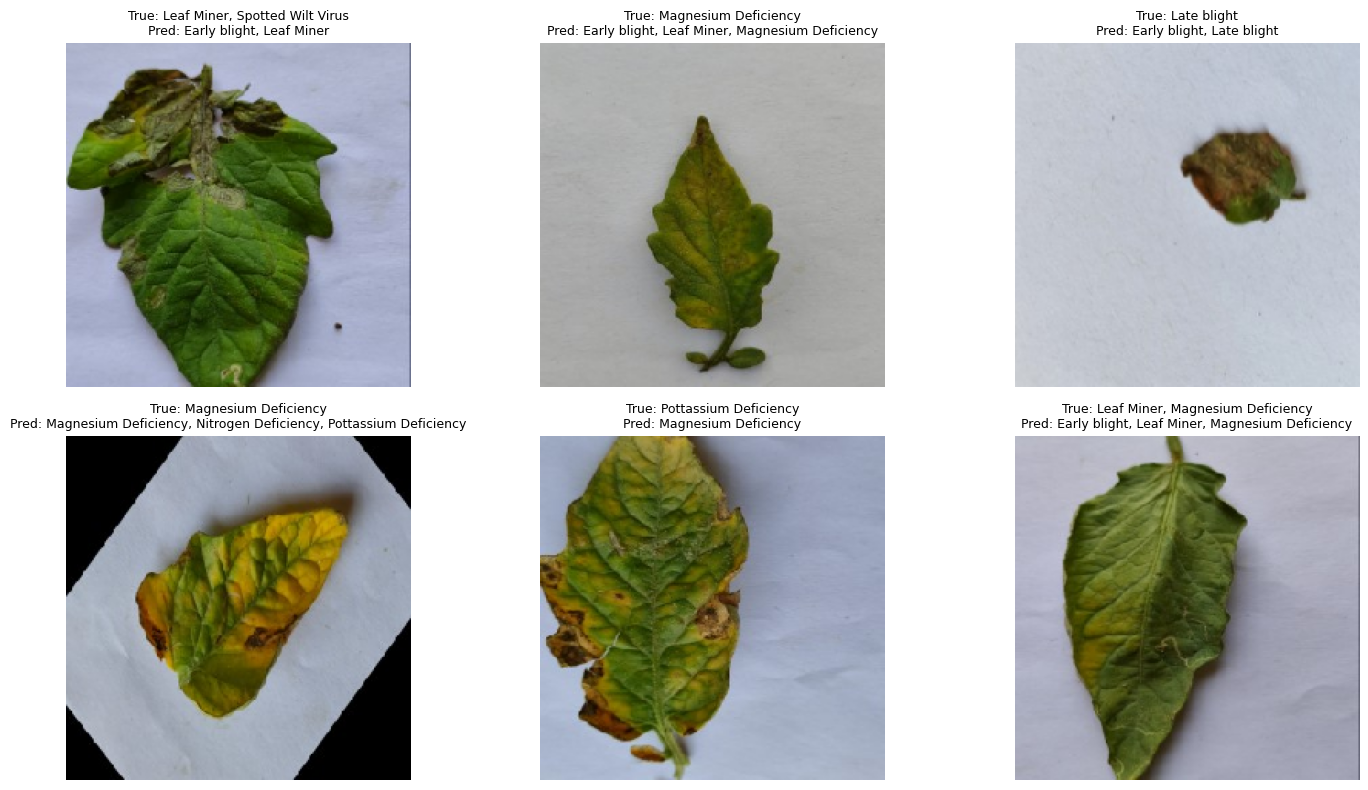

In [23]:
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

# Wir nehmen z.B. den Test-DF, du kannst auch val_df nehmen
N_EXAMPLES = 6
sample_df = test_df.sample(N_EXAMPLES, random_state=42)

def load_image_for_display_and_model(path):
    """Lädt Bild einmal für das Modell (0–255) und einmal für die Anzeige (0–1)."""
    img = keras.utils.load_img(path, target_size=IMG_SIZE)
    img_array = keras.utils.img_to_array(img)          # 0–255, float32
    img_display = img_array / 255.0                    # 0–1, für plt.imshow
    return img_array, img_display

images_display = []
true_labels = []
pred_labels = []
pred_probs = []

for _, row in sample_df.iterrows():
    img_model, img_disp = load_image_for_display_and_model(row["filepath"])
    images_display.append(img_disp)

    # echte Labels als 0/1-Vektor
    true = row[DISEASE_COLS].values.astype(int)
    true_labels.append(true)

    # Vorhersage des Modells
    probs = plant_cnn.predict(np.expand_dims(img_model, axis=0), verbose=0)[0]
    pred_probs.append(probs)

    # Binär nach deinen Thresholds
    bin_pred = (probs >= THRESHOLDS).astype(int)
    pred_labels.append(bin_pred)

def decode_labels(binary_array, label_names=DISEASE_COLS):
    """Gibt die Krankheitsnamen zurück, bei denen der Eintrag 1 ist."""
    return [label_names[i] for i, val in enumerate(binary_array) if val == 1]

plt.figure(figsize=(15, 8))

for i in range(N_EXAMPLES):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images_display[i])
    plt.axis("off")

    true_txt = ", ".join(decode_labels(true_labels[i])) or "None"
    pred_txt = ", ".join(decode_labels(pred_labels[i])) or "None"

    title = f"True: {true_txt}\nPred: {pred_txt}"
    plt.title(title, fontsize=9)

plt.tight_layout()
plt.show()


In [27]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow import keras

# Sicherstellen, dass IMG_SIZE existiert (sollte bei dir schon da sein)
IMG_SIZE = (224, 224)

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, class_index):
    """
    img_array: (1, H, W, 3), Werte 0–255 (wie beim Training vor Rescaling)
    class_index: Index in DISEASE_COLS, für den die Heatmap gebaut wird
    """
    last_conv_layer = model.get_layer(last_conv_layer_name)
    grad_model = keras.models.Model(
        [model.inputs],
        [last_conv_layer.output, model.output],
    )

    # Gradient der Zielklasse wrt. Feature-Maps
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        target = predictions[:, class_index]  # Multi-Label: einzelne Sigmoid-Output

    grads = tape.gradient(target, conv_outputs)

    # Gradients räumlich mitteln
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # (C,)

    conv_outputs = conv_outputs[0]  # (H, W, C)
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]  # (H, W, 1)
    heatmap = tf.squeeze(heatmap)

    # Nur positive Beiträge + Normalisierung 0–1
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def show_gradcam_for_image(
    img_path,
    model,
    last_conv_layer_name,
    class_index,
    class_name=None,
    thresholds=THRESHOLDS,
):
    """
    Zeigt Originalbild + Grad-CAM für eine gewählte Klasse.
    class_index: Index in DISEASE_COLS
    class_name:  Anzeigename (wenn None, wird DISEASE_COLS[class_index] genutzt)
    """
    if class_name is None:
        class_name = DISEASE_COLS[class_index]

    # Bild laden wie beim Training (0–255)
    img = keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras.utils.img_to_array(img)          # 0–255
    input_array = np.expand_dims(img_array, axis=0)

    # Vorhersage ausgeben
    probs = model.predict(input_array, verbose=0)[0]
    print("Scores pro Krankheit:")
    for name, p, thr in zip(DISEASE_COLS, probs, thresholds):
        print(f"{name:25s}: p={p:.3f}  thr={thr:.3f}")
    print(f"\nFokus-Klasse '{class_name}': p={probs[class_index]:.3f}")

    # Heatmap berechnen
    heatmap = make_gradcam_heatmap(
        input_array, model, last_conv_layer_name, class_index
    )

    # Heatmap einfärben
    heatmap_uint8 = np.uint8(255 * heatmap)
    colormap = cm.get_cmap("jet")
    colored_heatmap = colormap(np.arange(256))[:, :3]  # (256, 3)
    colored_heatmap = colored_heatmap[heatmap_uint8]   # (H, W, 3)

    # Auf Bildgröße bringen
    colored_heatmap = tf.image.resize(
        np.expand_dims(colored_heatmap, axis=0),
        IMG_SIZE,
    ).numpy()[0]

    # Overlay aus Original (0–1) + Heatmap
    alpha = 0.4
    img_display = img_array.astype("float32") / 255.0
    overlay = img_display * (1 - alpha) + colored_heatmap * alpha
    overlay = np.clip(overlay, 0, 1)

    # Plotten
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(img_display)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title(f"Grad-CAM – {class_name}")
    plt.imshow(overlay)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


In [29]:
from tensorflow import keras

# sicherstellen, dass plant_cnn existiert (Modell gebaut/geladen)
plant_cnn.summary(line_length=120)

# Alle Conv2D-Schichten auflisten
conv_layer_names = [
    layer.name
    for layer in plant_cnn.layers
    if isinstance(layer, keras.layers.Conv2D)
]

print("Conv-Schichten im Modell:")
print(conv_layer_names)

# Die letzte Conv-Schicht nehmen
last_conv_layer_name = conv_layer_names[-1]
print("Letzte Conv-Schicht für Grad-CAM:", last_conv_layer_name)


Model: "plant_cnn_multilabel"
________________________________________________________________________________________________________________________
 Layer (type)                                         Output Shape                                    Param #           
 input_2 (InputLayer)                                 [(None, 224, 224, 3)]                           0                 
                                                                                                                        
 data_augmentation (Sequential)                       (None, 224, 224, 3)                             0                 
                                                                                                                        
 rescale (Rescaling)                                  (None, 224, 224, 3)                             0                 
                                                                                                                        
 c

### Grad-CAM: Visualisierung der relevanten Bildbereiche

Mit Grad-CAM wird für ein ausgewähltes Bild und ein bestimmtes Krankheitslabel visualisiert, **auf welche Bildbereiche das Modell bei seiner Entscheidung besonders stark achtet**.  

Dabei wird eine Heatmap über das Originalbild gelegt:
- rote/gelbe Regionen = Bereiche, die stark zur Vorhersage des gewählten Labels beitragen,
- blaue/kalte Regionen = weniger relevante Bildbereiche.

So lässt sich nachvollziehen, ob das Modell tatsächlich die kranken Blattbereiche (z.B. Flecken, Verfärbungen) und nicht zufällige Hintergründe für seine Entscheidung nutzt.


Scores pro Krankheit:
Early blight             : p=0.619  thr=0.400
Late blight              : p=0.232  thr=0.400
Leaf Miner               : p=0.788  thr=0.450
Magnesium Deficiency     : p=0.224  thr=0.500
Nitrogen Deficiency      : p=0.005  thr=0.500
Pottassium Deficiency    : p=0.001  thr=0.900
Spotted Wilt Virus       : p=0.793  thr=0.900

Fokus-Klasse 'Leaf Miner': p=0.788


/var/folders/t8/prdvm2s15t59h3tqywj46zqw0000gn/T/ipykernel_6403/65672292.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("jet")


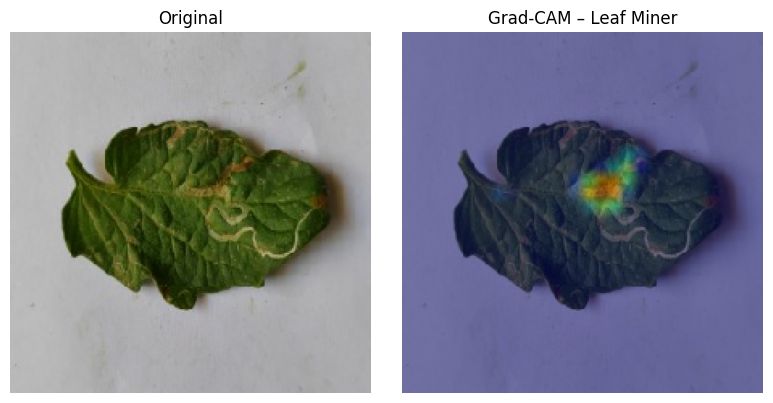

In [37]:
# Beispiel: Grad-CAM für Leaf Miner
img_path = "/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning/dataset2/test/IMG20220323103631.jpg"

show_gradcam_for_image(
    img_path=img_path,
    model=plant_cnn,
    last_conv_layer_name=last_conv_layer_name,
    class_index=DISEASE_COLS.index("Leaf Miner"),
    class_name="Leaf Miner",
)


### Visualisierung der Convolutional Layer (Feature Maps)

In dieser Zelle werden die **Aktivierungen der ersten Convolutional Layer** für ein Beispielbild dargestellt.  
Jede kleine Kachel (Feature Map) zeigt, **wie ein bestimmter Filter** im Netzwerk auf das Bild reagiert.

- Convolutional Layer bestehen aus vielen Filtern, die z.B. Kanten, Texturen, Flecken oder Farbkontraste erkennen.
- Frühe Layer reagieren eher auf einfache Muster (z.B. horizontale/vertikale Kanten, Helligkeitsunterschiede),
- tiefere Layer kombinieren diese zu komplexeren Merkmalen (z.B. krankheitsspezifische Fleckenstrukturen).

Die Visualisierung macht sichtbar, **welche Arten von Mustern** das CNN intern aus dem Bild extrahiert, bevor am Ende die Multi-Label-Klassifikation erfolgt.
::contentReference[oaicite:0]{index=0}


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow import keras

def build_activation_model(base_model):
    """
    Baut ein Modell, das für einen Input die Ausgaben aller Conv-Schichten liefert.
    """
    conv_outputs = [layer.output for layer in base_model.layers
                    if isinstance(layer, keras.layers.Conv2D)]
    conv_names   = [layer.name   for layer in base_model.layers
                    if isinstance(layer, keras.layers.Conv2D)]

    activation_model = Model(inputs=base_model.input, outputs=conv_outputs)
    return activation_model, conv_names


def visualize_conv_activations(
    img_path,
    model,
    img_size=IMG_SIZE,
    max_layers=3,
    filters_per_row=6,
):
    """
    Zeigt die Aktivierungen (Feature-Maps) der ersten max_layers Conv-Schichten.

    img_path: Pfad zum Bild
    model:    dein trainiertes Modell (plant_cnn)
    """
    # Bild laden
    img = load_img(img_path, target_size=img_size)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # (1,H,W,3)

    # Modell für Conv-Aktivierungen bauen
    activation_model, conv_layer_names = build_activation_model(model)

    # Aktivierungen berechnen
    activations = activation_model.predict(img_array, verbose=0)

    # Nur die ersten max_layers Conv-Schichten visualisieren
    for layer_name, layer_activation in zip(conv_layer_names[:max_layers],
                                            activations[:max_layers]):

        n_features = layer_activation.shape[-1]  # Anzahl Filter
        size = layer_activation.shape[1]         # Höhe/Breite (Feature-Map)

        n_cols = filters_per_row
        n_rows = max(1, n_features // n_cols)

        # Um nicht zu riesig zu werden, z.B. max. 8 Zeilen
        n_rows = min(n_rows, 8)
        n_features_to_show = n_cols * n_rows

        display_grid = np.zeros((size * n_rows, size * n_cols))

        for row in range(n_rows):
            for col in range(n_cols):
                idx = col + row * n_cols
                if idx >= n_features_to_show:
                    continue

                channel_image = layer_activation[0, :, :, idx]

                # Normalisieren für eine schöne Darstellung
                channel_image -= channel_image.mean()
                channel_image /= (channel_image.std() + 1e-5)
                channel_image = channel_image * 64 + 128
                channel_image = np.clip(channel_image, 0, 255).astype("uint8")

                r_start = row * size
                r_end   = (row + 1) * size
                c_start = col * size
                c_end   = (col + 1) * size

                display_grid[r_start:r_end, c_start:c_end] = channel_image

        scale = 1.0 / size
        plt.figure(figsize=(scale * display_grid.shape[1],
                            scale * display_grid.shape[0]))
        plt.title(f"Aktivierungen: {layer_name}")
        plt.grid(False)
        plt.imshow(display_grid, aspect="auto", cmap="viridis")
        plt.axis("off")
        plt.show()


2025-12-02 20:42:17.385138: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


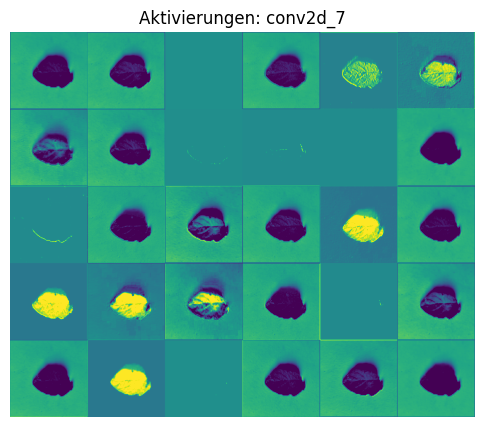

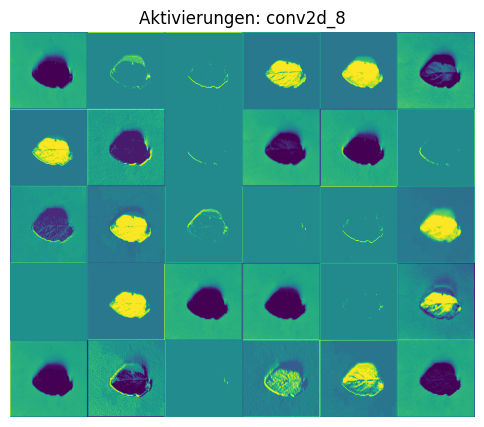

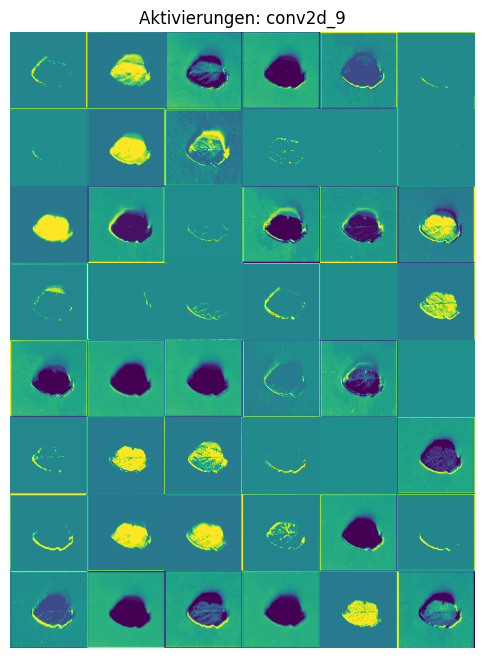

In [39]:
# Beispielbild aus deinem dataset2 (Pfad anpassen!)
img_path = "/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning/dataset2/test/IMG20220323111607.jpg"

visualize_conv_activations(
    img_path=img_path,
    model=plant_cnn,
    img_size=IMG_SIZE,
    max_layers=3,       # z.B. die ersten 3 Conv-Schichten
    filters_per_row=6,  # wie viele Filter nebeneinander
)


2025-12-02 19:57:59.630565: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


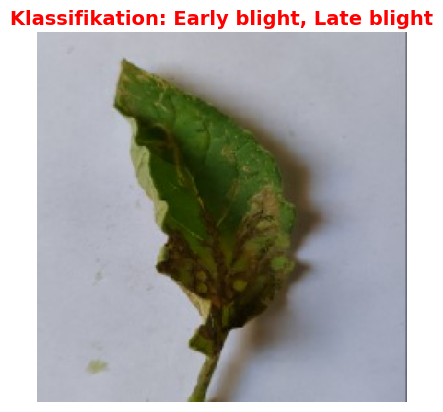

Scores und Thresholds pro Krankheit:
* Early blight             : p=0.621  |  thr=0.400
* Late blight              : p=0.606  |  thr=0.400
  Leaf Miner               : p=0.386  |  thr=0.450
  Magnesium Deficiency     : p=0.202  |  thr=0.500
  Nitrogen Deficiency      : p=0.112  |  thr=0.500
  Pottassium Deficiency    : p=0.181  |  thr=0.900
  Spotted Wilt Virus       : p=0.582  |  thr=0.900

Aktive Labels (nach Logik): Early blight, Late blight


(array([0.6205294 , 0.6055548 , 0.38646245, 0.20210806, 0.11224476,
        0.18111464, 0.5816541 ], dtype=float32),
 ['Early blight', 'Late blight'])

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow import keras

# ---------------------------------------------------
# Modell laden (nur für Inferenz, deshalb compile=False)
# ---------------------------------------------------
# Falls du lieber das finale Modell statt des Best-Checkpoints laden willst,
# nimm: "plant_cnn_from_scratch_multilabel_dataset2_weighted.keras"
plant_cnn = keras.models.load_model(
    "plant_cnn_multilabel_weighted_best.keras",
    compile=False
)

# Bildgröße wie beim Training
IMG_SIZE = (224, 224)

# Reihenfolge der Krankheiten (muss zur Output-Reihenfolge im Modell passen)
# -> sollte identisch zu dem DISEASE_COLS oben im Notebook sein.
DISEASE_COLS = [
    "Early blight",
    "Late blight",
    "Leaf Miner",
    "Magnesium Deficiency",
    "Nitrogen Deficiency",
    "Pottassium Deficiency",
    "Spotted Wilt Virus",
]

# ---------------------------------------------------
# WICHTIG:
# Die Zellen zur Threshold-Berechnung müssen vorher gelaufen sein,
# so dass THRESHOLDS existiert, z. B.:
# THRESHOLDS = np.array([...], dtype="float32")
# ---------------------------------------------------

def predict_image_plant_cnn(
    img_path,
    model=plant_cnn,
    thresholds=THRESHOLDS,  # per-Label-Thresholds (von Val-Set + manueller Feineinstellung)
    min_labels=1,           # mindestens so viele Labels anzeigen
    top_k=None              # optional: höchstens top_k Labels
):
    # --- Bild laden ---
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    # kein /255 – Rescaling passiert im Modell über den Rescaling-Layer
    x = np.expand_dims(img_array, axis=0)

    # --- Vorhersage ---
    probs = model.predict(x, verbose=0)[0]  # Vektor (NUM_LABELS,)

    # 1) Labels über ihrem individuellen Threshold
    thresholds = np.array(thresholds, dtype="float32")
    active_idx = np.where(probs >= thresholds)[0]

    # 2) Falls gar nichts über Threshold -> mind. min_labels mit höchstem Score
    if active_idx.size == 0:
        active_idx = np.argsort(probs)[-min_labels:]

    # 3) Falls sehr viele aktiv -> auf top_k mit höchstem Score begrenzen
    if top_k is not None and active_idx.size > top_k:
        top_local = np.argsort(probs[active_idx])[-top_k:]
        active_idx = active_idx[top_local]

    # finale aktiven Labels
    active_labels = [DISEASE_COLS[i] for i in active_idx]

    if not active_labels:
        label_str = "keine Krankheit erkannt"
        color = "green"
    else:
        label_str = ", ".join(active_labels)
        color = "red"

    # --- Anzeige ---
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Klassifikation: {label_str}", color=color, fontsize=14, weight="bold")
    plt.show()

    # --- Detailausgabe ---
    print("Scores und Thresholds pro Krankheit:")
    for name, p, t in zip(DISEASE_COLS, probs, thresholds):
        flag = "*" if name in active_labels else " "
        print(f"{flag} {name:25s}: p={p:.3f}  |  thr={t:.3f}")

    print(f"\nAktive Labels (nach Logik): {label_str}")

    return probs, active_labels


# Beispielaufruf
predict_image_plant_cnn(
    "/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning/dataset2/test/IMG20220323094749.jpg",
    top_k=3   # kannst du variieren (z.B. 2 oder 3)
)


In [19]:
import matplotlib.pyplot as plt

# Loss
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"],     label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.title("Train vs. Val Loss")
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'history' is not defined

<Figure size 600x400 with 0 Axes>

In [20]:
import numpy as np
from sklearn.metrics import multilabel_confusion_matrix

# 0/1-Vorhersagen nach deinen Thresholds
y_hat = (y_pred >= THRESHOLDS).astype("int32")

# 2x2-Confusion-Matrix pro Label
cm = multilabel_confusion_matrix(y_true, y_hat)

# Textausgabe wie TP/FP/FN/TN
for i, name in enumerate(DISEASE_COLS):
    tn, fp, fn, tp = cm[i].ravel()
    print(f"\n{name}")
    print(f"  TN (True 0, Pred 0): {tn}")
    print(f"  FP (True 0, Pred 1): {fp}")
    print(f"  FN (True 1, Pred 0): {fn}")
    print(f"  TP (True 1, Pred 1): {tp}")



Early blight
  TN (True 0, Pred 0): 288
  FP (True 0, Pred 1): 721
  FN (True 1, Pred 0): 17
  TP (True 1, Pred 1): 98

Late blight
  TN (True 0, Pred 0): 722
  FP (True 0, Pred 1): 220
  FN (True 1, Pred 0): 9
  TP (True 1, Pred 1): 173

Leaf Miner
  TN (True 0, Pred 0): 392
  FP (True 0, Pred 1): 315
  FN (True 1, Pred 0): 44
  TP (True 1, Pred 1): 373

Magnesium Deficiency
  TN (True 0, Pred 0): 699
  FP (True 0, Pred 1): 123
  FN (True 1, Pred 0): 103
  TP (True 1, Pred 1): 199

Nitrogen Deficiency
  TN (True 0, Pred 0): 831
  FP (True 0, Pred 1): 200
  FN (True 1, Pred 0): 17
  TP (True 1, Pred 1): 76

Pottassium Deficiency
  TN (True 0, Pred 0): 1081
  FP (True 0, Pred 1): 27
  FN (True 1, Pred 0): 7
  TP (True 1, Pred 1): 9

Spotted Wilt Virus
  TN (True 0, Pred 0): 942
  FP (True 0, Pred 1): 0
  FN (True 1, Pred 0): 182
  TP (True 1, Pred 1): 0


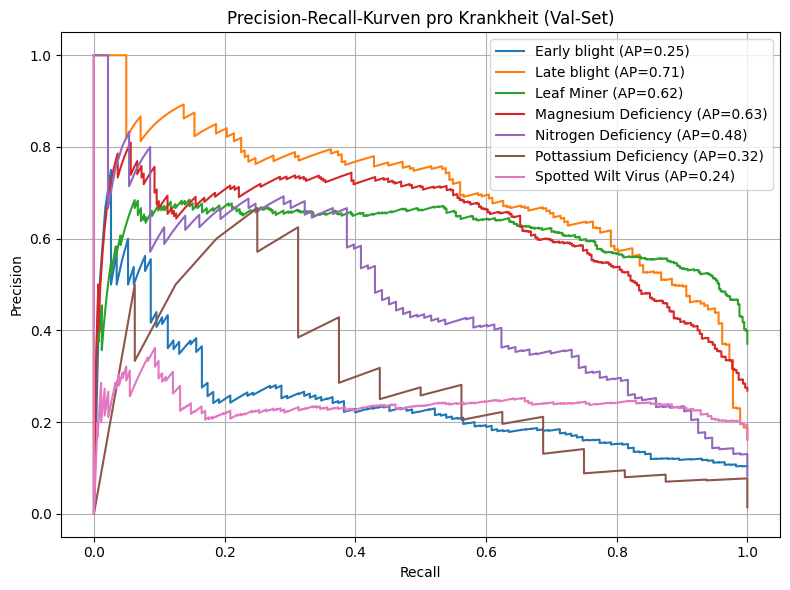

In [49]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))

for i, name in enumerate(DISEASE_COLS):
    y_true_label = y_true[:, i]
    y_score_label = y_pred[:, i]

    # Nur plotten, wenn es überhaupt positive Beispiele gibt
    if y_true_label.sum() == 0:
        continue

    precision, recall, _ = precision_recall_curve(y_true_label, y_score_label)
    ap = average_precision_score(y_true_label, y_score_label)

    plt.plot(recall, precision, label=f"{name} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall-Kurven pro Krankheit (Val-Set)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Train Test Val split als Grafik darstellen**
**Visualizierung von Rohdaten (vor dem Preprocessing-Schritt)**
**Visualizierung von bereits vorverarbeitenden Daten (sprich nach dem Preprocessing-Schritt)**
**Visualizierung der Loss- und Accuracy-Kurven**

**Liste der Herangehenweise:**
***Wie haben wir die Hyperparamter so gewählt?***
- Batch-Size
- Epochen
- usw.

***Weshalb haben wir uns für die entsprechenden Vorverarbeitungsschritten entschieden?***


***Weshalb haben wir die entsprechenden Metriken und Funktionen ausgewählt? (Im Kontext des verwendeten Datensatz erklären!!)***
- Verlustfunktion (aktuell verwenden wir: binary_crossentropy)
- Optimirungfunktion (aktuell verwenden wir: Adam-Optimizer vllt. AdamW-Optimizer)
- Bewertungsmetriken (aktuell verwenden wir: BinaryAccuracy und AUC)
- Learningrate (aktuell verwenden wir: 1e-4)


## Fazit – Einordnung des Modells

Insgesamt funktioniert das CNN **solide**, aber es erreicht das Ziel „mindestens zwei Krankheiten pro Blatt sicher erkennen“ noch nicht stabil. Die wichtigsten Gründe:

- **Unbalancede & begrenzte Datenmenge**  
  Einige Krankheiten (z.B. Leaf Miner, Late blight) haben viele Beispiele, andere (v.a. Potassium Deficiency, Spotted Wilt Virus) sehr wenige. Dadurch lernt das Modell manche Klassen gut, andere nur schwach.

- **Schwieriges Multi-Label-Problem**  
  Mehrere Krankheiten liegen gleichzeitig auf einem Blatt und sehen sich visuell ähnlich (Flecken, Verfärbungen). Das macht die Trennung deutlich schwerer als bei einfachem Single-Label („eine Klasse pro Bild“).

- **Label-/Datenrauschen**  
  Die Annotationen im Datensatz sind nicht perfekt: Symptome überlappen, manche Bilder sind schlecht belichtet, teilweise ist unklar, ob eine zweite Krankheit wirklich vorliegt. Das senkt vor allem die Precision bei seltenen Klassen.

- **Modell & Training sind grundsätzlich ok**  
  Loss- und Accuracy-Kurven zeigen **kein starkes Overfitting**, und für mehrere Klassen liegen Precision/Recall bzw. AP-Werte im guten Bereich. Die Hauptgrenze ist daher **nicht** die Architektur, sondern die Datenqualität und -verteilung.

Kurz gesagt: Das Modell nutzt die vorhandenen Daten gut aus, stößt aber wegen **Datenlage + Multi-Label-Komplexität** an Grenzen – deshalb werden Krankheits-Kombinationen noch nicht so zuverlässig erkannt, wie es ideal wäre.


eventuell early_stopping rausnehmen andere alternative

weighted binary cross weiter verwernden 

weiter an den threshold schrauben um zu schauen ob das modell besser wird
    -automatische treshold mit pred, pos weights